In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score

In [2]:
df = pd.read_csv('dataset_2.csv')
df

,sensor_x,sensor_y,sensor_z,defect
0,-1.751,-4.923,-0.663,1
1,-1.427,1.577,-0.086,0
2,2.262,-5.324,-0.601,1
3,-0.165,3.655,-0.630,1
4,0.192,-1.645,-0.332,0
...,...,...,...,...
995,-2.554,2.140,-1.031,1
996,2.596,-3.988,-0.457,1
997,-1.789,1.244,0.239,0
998,-4.785,-0.213,-0.923,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sensor_x  1000 non-null   float64
 1   sensor_y  1000 non-null   float64
 2   sensor_z  1000 non-null   float64
 3   defect    1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [4]:
x = df.drop(columns=['defect'])
y = df['defect']

In [5]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, random_state=42, train_size=0.8, stratify=y)

In [6]:
y.value_counts()

defect
1    500
0    500
Name: count, dtype: int64

In [7]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [8]:
y_pred = model.predict(xtest)
y_pred

array([0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 1], dtype=int64)

In [9]:
accuracyScore = accuracy_score(ytest, y_pred)
accuracyScore

0.425

In [10]:
recallScore = recall_score(ytest, y_pred)
recallScore

0.38

In [11]:
precisionScore = precision_score(ytest, y_pred)
precisionScore

0.4175824175824176

In [12]:
f1Score = f1_score(ytest, y_pred)
f1Score

0.39790575916230364

In [13]:
train_pred = model.predict(xtrain)
test_pred = model.predict(xtest)

train_accuracy = accuracy_score(ytrain, train_pred)
test_accuracy = accuracy_score(ytest, test_pred)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.52625
Test Accuracy: 0.425


In [14]:
from sklearn.tree import DecisionTreeClassifier

treeModel = DecisionTreeClassifier(random_state=42)
treeModel.fit(xtrain, ytrain)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
ypred=treeModel.predict(xtest)
ypred

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1], dtype=int64)

In [16]:
treePrecisionScore = precision_score(ytest, ypred)
treePrecisionScore

0.98

In [17]:
treeRecallScore = recall_score(ytest, ypred)
treeRecallScore

0.98

In [18]:
treeAccurayScore = accuracy_score(ytest, ypred)
treeAccurayScore

0.98

In [19]:
treeF1Score = f1_score(ytest, ypred)
treeF1Score

0.98

In [21]:
trainPred = treeModel.predict(xtrain)
testPred = treeModel.predict(xtest)

trainAccuracy = accuracy_score(ytrain, trainPred)
testAccuracy = accuracy_score(ytest, testPred)

print("Train Accuracy:", trainAccuracy)
print("Test Accuracy:", testAccuracy)

Train Accuracy: 1.0
Test Accuracy: 0.98


#### The Decision Tree achieved 100% training accuracy and 98% testing accuracy. Since the testing accuracy is also very high and close to the training accuracy, the model generalizes well on this train-test split.

In [25]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    treeModel, xtrain, ytrain, cv=5, scoring="accuracy"
)
scores

array([0.98125, 0.96875, 0.96875, 0.98125, 0.96875])

In [26]:
mean_accuracy = scores.mean()

print("Mean CV Accuracy:", mean_accuracy)

Mean CV Accuracy: 0.9737500000000001


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [31]:
gridModel = GridSearchCV(
    estimator= treeModel,
    param_grid={
    "max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
    },
    cv = 5,
    scoring='accuracy'
)

In [32]:
gridModel.fit(xtrain, ytrain)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [33]:
gridModel.best_params_

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}

In [34]:
gridModel.best_score_

0.9800000000000001

In [35]:
best_model = gridModel.best_estimator_
final_pred = best_model.predict(xtest)

print("Accuracy:", accuracy_score(ytest, final_pred))
print("Precision:", precision_score(ytest, final_pred))
print("Recall:", recall_score(ytest, final_pred))
print("F1 Score:", f1_score(ytest, final_pred))

Accuracy: 0.985
Precision: 0.9801980198019802
Recall: 0.99
F1 Score: 0.9850746268656716


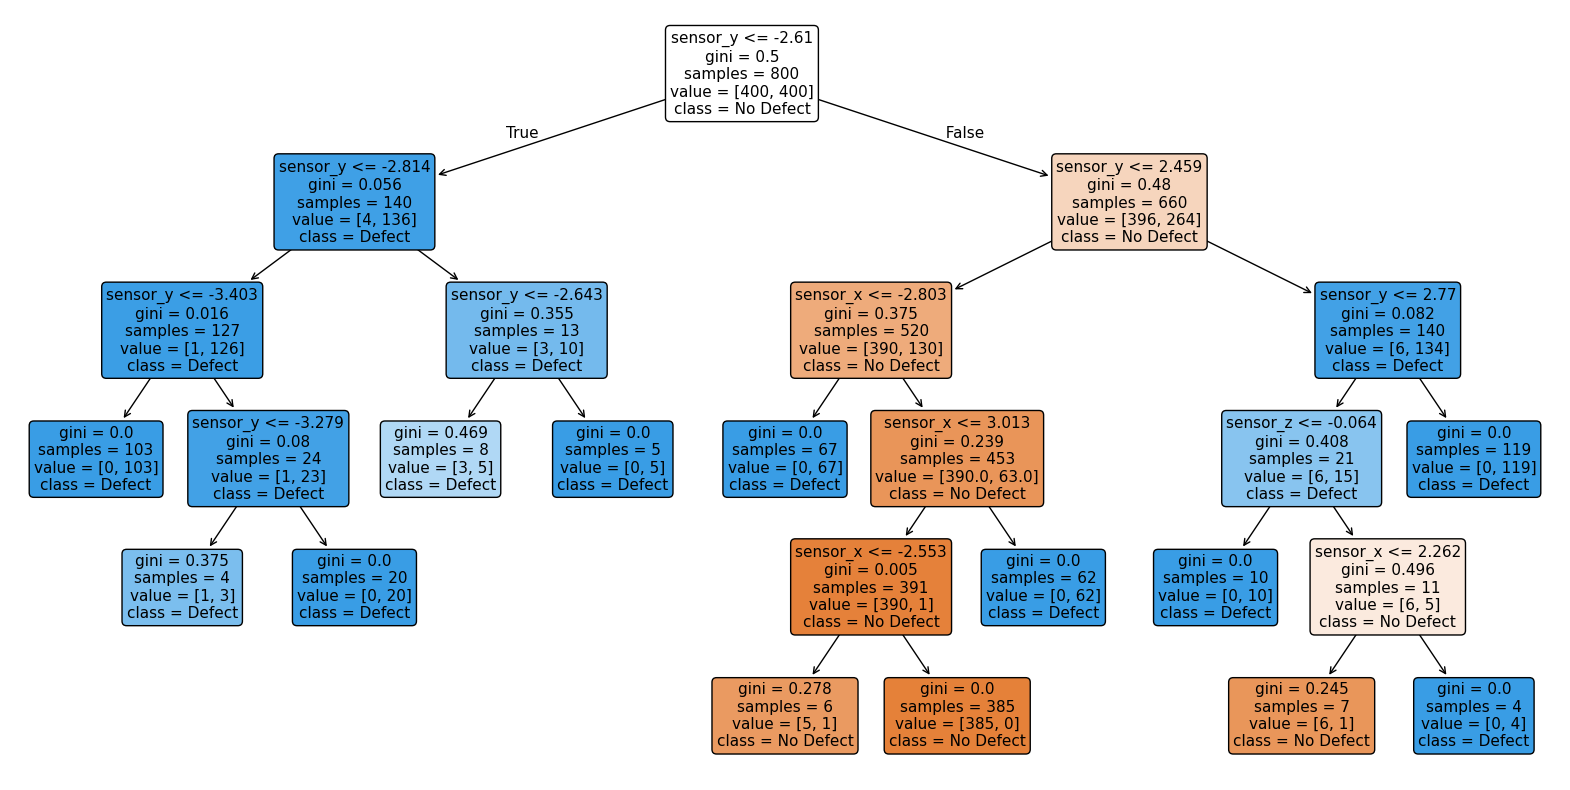

In [36]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    best_model,
    feature_names=x.columns,
    class_names=["No Defect", "Defect"],
    filled=True,
    rounded=True
)

plt.show()